In [38]:
import os
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, ToolMessage

load_dotenv()
if os.getenv("GROQ_API_KEY"):
    print("API Key Loaded")

API Key Loaded


In [39]:
llm = ChatGroq(model = "openai/gpt-oss-120b")

### **Pydantic LLM Schema**

In [40]:
from pydantic import BaseModel, Field
from typing import List, TypedDict

class llm_schema(BaseModel):
    tasks:List[str] = Field(...,description = "A List Of Tasks To Be Performed By The Worker")
    
llm_with_schema = llm.with_structured_output(llm_schema)

### **Graph Schema**

In [41]:
class graph_schema(TypedDict):
    tasks:List[str]
    query:str
    result:List[str]
    summary:str

### **Creating Orchestrator Node**

In [42]:
def orchestrator_node(state:graph_schema) -> graph_schema:
    user_query = state['query']
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system","you are a orchestrator that breaks down a user query into tasks for the worker."),
            ("user",f"User Query: {user_query}. Please generate one prompt for the worker to complete.")
        ]
    )
    
    chain = prompt | llm_with_schema
    
    response = chain.invoke({"query":user_query})
    
    state['tasks'] = response.tasks
    
    return state

### **Worker Node**

In [43]:
def execute(query:str) :
    
    response = llm.invoke(f"Please Execute This task {query} ")
    
    return response.content

In [44]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state:graph_schema) -> graph_schema:
    
    tasks = state['tasks']
    results = []
    
    with ThreadPoolExecutor(max_workers= len(tasks)) as executer:
        results_futures = executer.map(execute, tasks)
        for result in results_futures:
                   results.append(result)
    
    state['result'] = results
    
    return state

### **Collector Node**

In [45]:
def collector_node(state:graph_schema):
    results = state['result']
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system","You Are A Collector That Summarizes The Results From The Worker"),
            ("user","Here are the results from the worker: {results}. Please summarize these results")
        ]
    )
    
    chain = prompt | llm
    
    summary = chain.invoke({"results":results})
    
    state['summary'] = summary
    
    return state

### **Creating Graph And Executing**

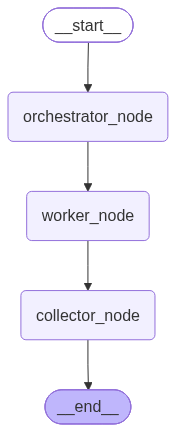

In [46]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("orchestrator_node",orchestrator_node)
graph.add_node("worker_node",worker_node)
graph.add_node("collector_node",collector_node)

graph.add_edge(START, "orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

complex_graph = graph.compile()
complex_graph

In [47]:
complex_graph.invoke({
    "query":"Who Is Elon Musk & His Child Names",
    "tasks":[],
    "result":[],
    "summary":""
    })

{'tasks': ['Provide a concise biography of Elon Musk, covering his major achievements and roles.',
  "List the full names of all of Elon Musk's children, including any known nicknames or variations."],
 'query': 'Who Is Elon Musk & His Child Names',
 'result': ['**Elon Musk – Concise Biography**\n\n**Full Name:** Elon Reeve Musk  \n**Born:** June 28, 1971, Pretoria, South Africa  \n**Nationality:** South African‑born Canadian‑American (dual citizenship)\n\n---\n\n### Early Life & Education\n- **Family:** Son of Maye Musk (model/dietitian) and Errol Musk (engineer).  \n- **Education:** Attended Pretoria Boys High School; moved to Canada at 17, enrolling at Queen’s University (1990‑1992). Transferred to the University of Pennsylvania, earning a B.S. in Physics and a B.S. in Economics (Wharton) in 1997.\n\n---\n\n### Entrepreneurial Milestones\n\n| Year | Venture | Role | Key Achievements |\n|------|----------|------|------------------|\n| **1995** | **Zip2** (online city guide) | Co‑foun